# 02 — Covariance Estimation

Compare four estimators and understand their practical differences.

**Key question**: How much does the choice of covariance estimator affect the final portfolio?

**Contents:**
1. Sample covariance (baseline)
2. Ledoit-Wolf shrinkage
3. EWMA (RiskMetrics)
4. Factor model (PCA)
5. Comparison: condition number, eigenvalue spectrum
6. Sensitivity analysis

In [8]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.estimators.covariance import (
    sample_covariance, ledoit_wolf_covariance, ewma_covariance,
    factor_covariance, is_positive_definite
)
from config import N_FACTORS, EWMA_LAMBDA

returns = pd.read_csv('../data/returns.csv', index_col=0, parse_dates=True)
print(f'Returns loaded: {returns.shape}')

Returns loaded: (149, 8)


## 1. Compute All Estimators

In [9]:
cov_sample = sample_covariance(returns)
cov_lw     = ledoit_wolf_covariance(returns)
cov_ewma   = ewma_covariance(returns, lam=EWMA_LAMBDA)
cov_factor, loadings, explained = factor_covariance(returns, n_factors=N_FACTORS)

for name, cov in [('Sample', cov_sample), ('LW', cov_lw), ('EWMA', cov_ewma), ('Factor', cov_factor)]:
    cond = np.linalg.cond(cov.values)
    pd_check = is_positive_definite(cov)
    print(f'{name:8s}: condition_number={cond:12.1f} | pos_definite={pd_check}')

Sample  : condition_number=       187.0 | pos_definite=True
LW      : condition_number=        45.3 | pos_definite=True
EWMA    : condition_number=       237.4 | pos_definite=True
Factor  : condition_number=        59.5 | pos_definite=True


## 2. Eigenvalue Spectrum

Ill-conditioned matrices have extreme eigenvalues. Shrinkage compresses the spectrum.

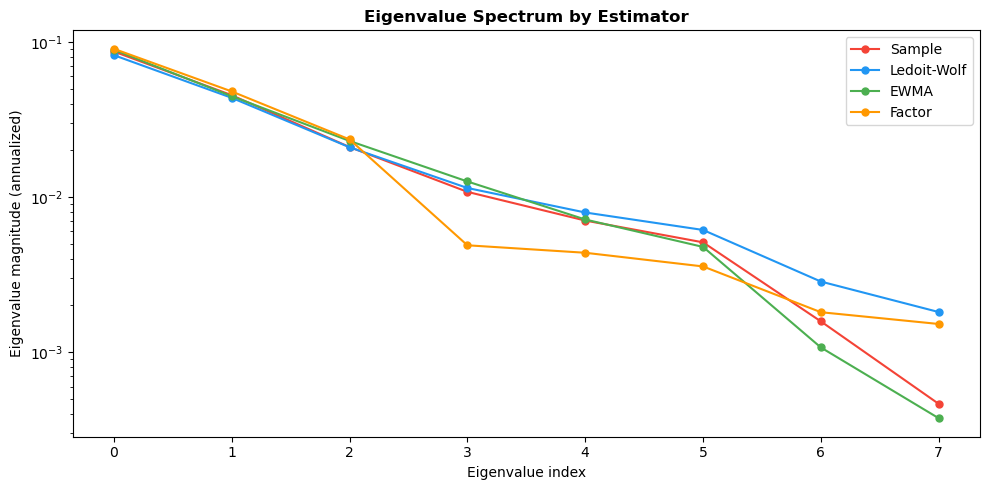

Large spread → poorly conditioned → optimizer will find extreme weights


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, cov, color in [('Sample', cov_sample, '#F44336'), ('Ledoit-Wolf', cov_lw, '#2196F3'),
                          ('EWMA', cov_ewma, '#4CAF50'), ('Factor', cov_factor, '#FF9800')]:
    eigvals = sorted(np.linalg.eigvalsh(cov.values), reverse=True)
    ax.plot(eigvals, 'o-', label=name, color=color, lw=1.5, ms=5)
ax.set_xlabel('Eigenvalue index')
ax.set_ylabel('Eigenvalue magnitude (annualized)')
ax.set_title('Eigenvalue Spectrum by Estimator', fontsize=12, fontweight='bold')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('../results/02_eigenvalues.png', dpi=150)
plt.show()
print('Large spread → poorly conditioned → optimizer will find extreme weights')

## 3. Factor Model: PCA Loadings & Explained Variance

In [11]:
print('\nVariance Explained by PCA Factors:')
for name, val in explained.items():
    bar = '█' * int(val * 50)
    print(f'  {name}: {val*100:5.1f}%  {bar}')

print(f'\nTotal explained: {explained.sum()*100:.1f}%')

print('\nFactor Loadings (beta of each asset on each PC):')
display(loadings.round(3))


Variance Explained by PCA Factors:
  PC1:  48.7%  ████████████████████████
  PC2:  25.5%  ████████████
  PC3:  11.8%  █████

Total explained: 86.0%

Factor Loadings (beta of each asset on each PC):


,PC1,PC2,PC3
SPY,0.417,-0.043,-0.366
EZU,0.547,-0.086,-0.280
EEM,0.515,-0.103,0.015
TLT,0.085,-0.484,0.162
LQD,0.174,-0.198,0.027
EMB,0.243,-0.151,0.021
GLD,0.173,-0.304,0.787
GSG,0.368,0.769,0.375


## 4. Volatility Estimates Comparison

Annualized Volatility Estimates (%):


,Sample,Ledoit-Wolf,EWMA,Factor
SPY,14.70,14.67,14.76,14.69
EZU,17.75,17.52,17.21,17.74
EEM,16.97,16.79,17.66,16.96
TLT,13.23,13.30,13.12,13.22
LQD,7.76,8.36,7.96,7.76
EMB,8.71,9.19,8.55,8.71
GLD,14.87,14.82,16.80,14.86
GSG,20.71,20.33,20.21,20.70


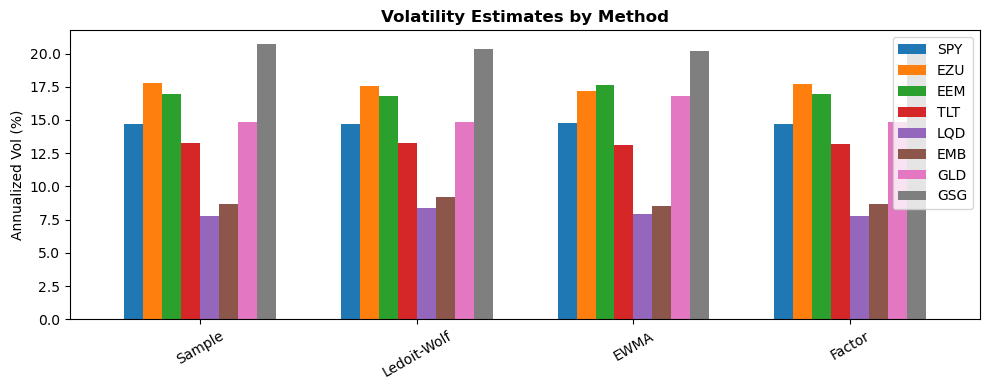

In [12]:
vols = pd.DataFrame({
    'Sample':      np.sqrt(np.diag(cov_sample.values)) * 100,
    'Ledoit-Wolf': np.sqrt(np.diag(cov_lw.values)) * 100,
    'EWMA':        np.sqrt(np.diag(cov_ewma.values)) * 100,
    'Factor':      np.sqrt(np.diag(cov_factor.values)) * 100,
}, index=returns.columns)

print('Annualized Volatility Estimates (%):')
display(vols.round(2))

fig, ax = plt.subplots(figsize=(10, 4))
vols.T.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Volatility Estimates by Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Annualized Vol (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
plt.tight_layout()
plt.savefig('../results/02_volatilities.png', dpi=150)
plt.show()

## 5. EWMA Rolling Volatility

EWMA captures volatility clustering (high-vol periods)

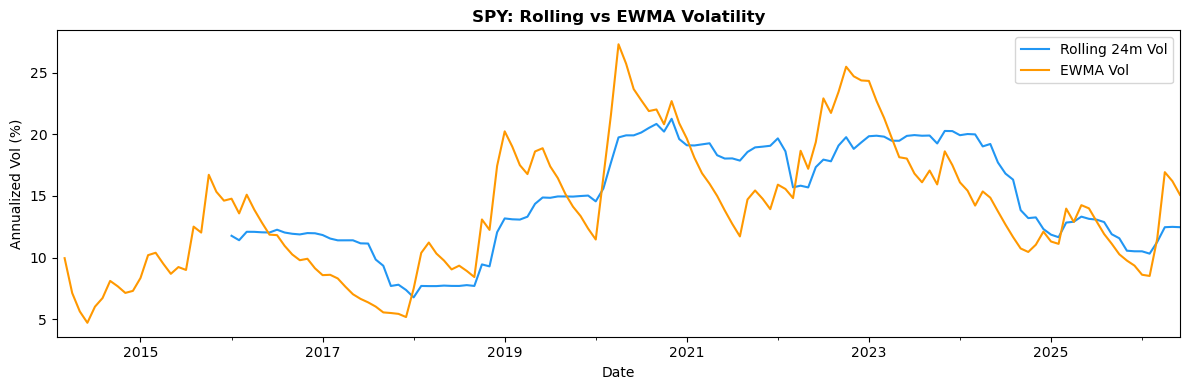


→ EWMA reacts faster to volatility spikes (2020 COVID, 2022 rate hikes)


In [13]:
# Rolling EWMA vol for SPY
from src.estimators.covariance import ewma_covariance

# Compute rolling EWMA vol with 24-month windows
spy_ret = returns['SPY']
roll_vol_ewma = spy_ret.ewm(span=12).std() * np.sqrt(12) * 100
roll_vol_static = spy_ret.rolling(24).std() * np.sqrt(12) * 100

fig, ax = plt.subplots(figsize=(12, 4))
roll_vol_static.plot(ax=ax, label='Rolling 24m Vol', color='#2196F3', lw=1.5)
roll_vol_ewma.plot(ax=ax, label='EWMA Vol', color='#FF9800', lw=1.5)
ax.set_title('SPY: Rolling vs EWMA Volatility', fontsize=12, fontweight='bold')
ax.set_ylabel('Annualized Vol (%)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/02_ewma_vol.png', dpi=150)
plt.show()
print('\n→ EWMA reacts faster to volatility spikes (2020 COVID, 2022 rate hikes)')

In [14]:
import pickle
covs = {'sample': cov_sample, 'ledoit_wolf': cov_lw, 'ewma': cov_ewma, 'factor': cov_factor}
for name, cov in covs.items():
    cov.to_csv(f'../data/cov_{name}.csv')
print('All covariance matrices saved ✓')

All covariance matrices saved ✓
